# Gradient verification for the 2D - non reactive transport (diffusion + advection), permeablity inversion from head - density flow

The goal here is to verify the correctness of the adjoint state method in HYTEC by comparing the results with the demonstrator's which are considered as correct.

In [1]:
import os
from pathlib import Path
import logging
import copy
import time
from typing import Dict, Generator, Iterable
import pyrtid
import pyrtid.forward as dmfwd
import pyrtid.inverse as dminv
import hytecio
import nested_grid_plotter
from nested_grid_plotter import (
    NestedGridPlotter,
    AnimatedPlotter,
    extract_frames_from_embedded_html_animation,
    multi_imshow,
)
from hytecio.core import (
    AdjustableParameter,
    HytecSimulation,
    ParameterFiles,
    Observable,
    ObservationType,
)

from hytecio.job_managers import (
    FrontalHytecRunner,
    JobConfig,
    SlurmHytecRunner,
    QsubHytecRunner,
)
import hytecio.core.model as hymd
from hytecio.utils import (
    StrEnum,
    is_tool,
    get_hytec_version,
    get_mpi_version,
    indices_to_hytec_node_number,
    hytec_node_number_to_indices,
    gen_random_ensemble,
    get_normalized_mean_from_lognormal_params,
    get_normalized_std_from_lognormal_params,
)
from hytecio.plot import plot_observed_vs_simulated
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.colors import LogNorm
from matplotlib.animation import HTMLWriter
from IPython.display import HTML
import numpy as np
import numpy.typing as npt
import pandas as pd
from scipy.ndimage import gaussian_filter
import gstools as gs

gs.config.USE_RUST = True  # Use the rust implementation of gstools

- Type hints definition for numpy arrays

In [2]:
NDArrayFloat = npt.NDArray[np.float_]
NDArrayInt = npt.NDArray[np.int_]

- Set-up logging level

In [3]:
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logging.info("this is a logging test")

INFO:root:this is a logging test


- Check package/software versions(slurm = clusterfon, qsub = Omines, frontal = local machine)
- Check package/software versions

In [4]:
logging.info(f"hytecio version = {hytecio.__version__}")
logging.info(f"nested_grid_plotter version = {nested_grid_plotter.__version__}")
logging.info(f"pyrtid version = {pyrtid.__version__}")


class RunnerType(StrEnum):
    FRONTAL = "frontal"
    QSUB = "qsub"
    SLURM = "slurm"
    UNKNOWN = "unknown"


hytec_paths = {
    RunnerType.FRONTAL: "hytec",
    RunnerType.QSUB: "/omines/home/public/Programs/HYTEC/hytec-4.7.4",
    RunnerType.SLURM: "/cluster/GEOSCIENCES/home/acollet/hytec/svn/build/bin/Release/hytec",
}

v = ""
runner_type = RunnerType.UNKNOWN
for k, v in hytec_paths.items():
    if is_tool(v):
        runner_type = k
        break

if runner_type == RunnerType.UNKNOWN:
    raise Exception("no valid hytec command found !")

# Path or alias to the hytec binary on your local machine.
hytec_binary_path_or_alias: str = v

logging.info(f"HYTEC version = {get_hytec_version(hytec_binary_path_or_alias)}")

mpi_binary_path_or_alias: str = {
    RunnerType.FRONTAL: "mpiexec",
    RunnerType.QSUB: "mpiexec",
    RunnerType.SLURM: "/cluster/GEOSCIENCES/home/apps/mpich/4.0.2/bin/mpiexec",
}[runner_type]

logging.info(f"mpiexec version = {get_mpi_version(mpi_binary_path_or_alias)}")

dos2unix_binary_path_or_alias = "dos2unix"

INFO:root:hytecio version = 0.1.5
INFO:root:nested_grid_plotter version = 0.1.0
INFO:root:pyrtid version = 0.1.0

INFO:root:HYTEC version = 4.7.4-r1680
INFO:root:mpiexec version = 4.1.1


- Create a directory to store the exported figures

In [5]:
ipynb_path = os.path.dirname(os.path.realpath("__file__"))
fig_save_path = Path(ipynb_path, "exported_figures")
fig_save_path.mkdir(parents=True, exist_ok=True)  # make sure that the directory exists

- Define some configurations for the plots

In [6]:
# Some configs for the plots
new_rc_params = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "DejaVu Sans"],
    "font.size": 16,
    "text.usetex": False,
    "savefig.format": "svg",
    "svg.fonttype": "none",  # to store text as text, not as path
    "savefig.facecolor": "w",
    "savefig.edgecolor": "k",
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "figure.facecolor": "w",
    "axes.facecolor": "w",
}
csfont = {"fontname": "Comic Sans MS"}
hfont = {"fontname": "Helvetica"}
plt.plot()
plt.close()  # required for the plot to update
plt.rcParams.update(new_rc_params)

## Forward problem

- Define a very simple pure transient density flow + transport (advection & diffusion) case in 2D.

In [7]:
nx = 21  # number of voxels along the x axis
ny = 8  # number of voxels along the y axis
nz = 1  # number of voxels along the y axis
# Give non regular dimensions to check if all is correct with mesh dimensions
dx = 5.0  # voxel dimension along the x axis
dy = 5.0
dz = 1.0  # voxel dimension along the y axis

nt = 1  # number of time steps
dt = 3600 * 6  # timestep in seconds
c0 = 0  # general initial cocentration
# Hydro parameters
D0 = 1e-8  # general initial diffusion coefficient [m2/s]
k0 = 1e-3  # general permeability
w0 = 0.23  # general porosity [fraction]
# Chemistry parameters
c0 = 0.0  # general initial concentration [molal]
c_inj = 1  # molal

storage_coefficient: float = 1e-4

initial_head_in_m = 0.0  # m
cst_head_left = 9  # m
cst_head_right = 9  # m

flow_regime = "transient"

crank_flow = 1.0
crank_diff = 1.0
crank_adv = 0.5

# Values for the x axis ()meters
x_positions_in_meters: NDArrayFloat = np.arange(nx) * dx + dx / 2

- Three observation wells

In [8]:
well_length = 1.0
production_locations = [(6, 3, 0), (14, 3, 0)]
injection_locations = [(2, 6, 0), (10, 6, 0), (18, 6, 0)]

- Create an initial "bumped" reference distribution for the permeability, and a flat one for the initial estimation.

In [9]:
# Create a Gaussian Covariance Model just for the example
# To vary the results, change the seed :)
seed = 19

min_val = 1e-7
max_val = 1e-3
# Compute the mean and the standard deviation that the distribution should have so that
# <99% of the values are between min and max ~ 6 sigmas
meanlog = (max_val + min_val) / 2.0
stdevlog = (max_val - min_val) / 2.0  # std ~ 1/6 of the distribution interval
len_scale: float = 2.0

mean = get_normalized_mean_from_lognormal_params(meanlog, stdevlog)
stdev = get_normalized_std_from_lognormal_params(meanlog, stdevlog)

perm_reference = gen_random_ensemble(
    model=gs.covmodel.Gaussian,
    normalizer=gs.normalizer.LogNormal,
    n_ensemble=1,
    var=stdev**2,
    len_scale=len_scale,
    mean=mean,
    nx=nx,
    ny=ny,
    nz=nz,
    seed=seed,
)[0, :, :, 0]


# Initial estimate = an homogeneous value
perm_estimate = np.ones((nx, ny)) * 2e-4  # m2/s

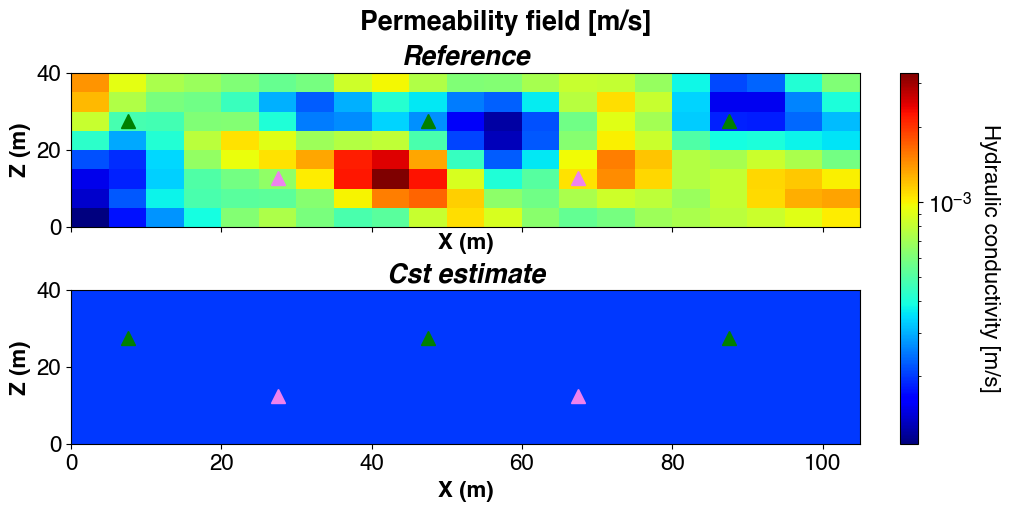

In [10]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (10, 5)},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1"], ["ax1-2"]], sharey=True, sharex=True)
    },
)

multi_imshow(
    axes=plotter.axes,
    fig=plotter.fig,
    data={
        "Reference": perm_reference,
        "Cst estimate": perm_estimate,
    },
    cbar_title="Hydraulic conductivity [m/s]",
    imshow_kwargs={
        "cmap": plt.get_cmap("jet"),
        "extent": [0.0, nx * dx, 0.0, ny * dy],
        "norm": LogNorm(),
    },
    xlabel="X (m)",
    ylabel="Z (m)",
)

plotter.subfigs["fig0"].suptitle("Permeability field [m/s]", fontweight="bold")

for ax in plotter.ax_dict.values():
    # Add some vertical lines to indicate the well
    for well_pos in production_locations:
        ax.plot(
            well_pos[0] * dx - dx / 2,
            well_pos[1] * dy - dy / 2,
            label="prod wells",
            marker="^",
            markersize=10,
            c="violet",
            linestyle="none",
        )

    for well_pos in injection_locations:
        ax.plot(
            well_pos[0] * dx - dx / 2,
            well_pos[1] * dy - dy / 2,
            label="inj wells",
            marker="^",
            markersize=10,
            c="g",
            linestyle="none",
        )

fname = "true_vs_estimated_initial_mineral_field"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

- Create the flowrates for the wells: 12 m3/h decreasing following an exponential... for the producers with a balanced injection (2 m3/h per associated cell for the injectors).

In [11]:
def gen_flowrates(amplitude: float, coef: float, nt: int, dt: float) -> NDArrayFloat:
    """Generate flowrates with a given amplitude and decrease coefficient.

    Parameters
    ----------
    amplitude : float
        Amplitude in m3/h.
    coef : float
        Decrease coefficient.
    nt : int
        Number of timesteps
    dt : float
        Timesteps.

    Returns
    -------
    np.ndarray
        The flowrates.
    """
    return amplitude * np.exp(coef * np.arange(nt) * dt)

- Generate a flowrates with an initial amplitude at 1 m3/h and plot it

Text(0.5, 0, 'time [d]')

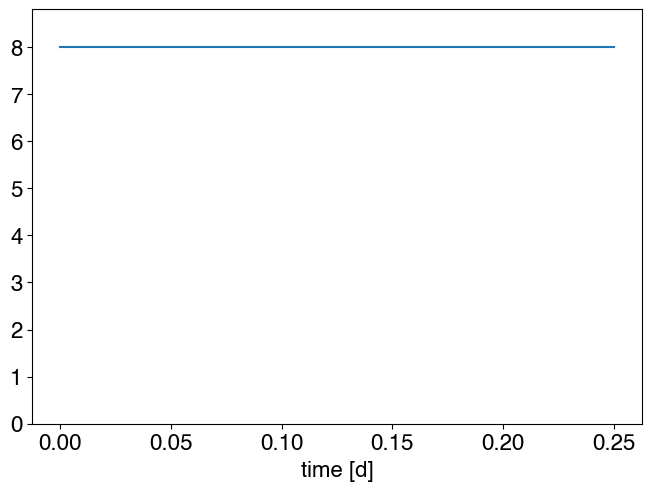

In [12]:
init_prod_flowrates = 8.0  # m3/s
# nt+1 because we consider the initial state too
flowrates = init_prod_flowrates * gen_flowrates(
    1.0, -0.0, nt + 1, dt=dt / 3600 / 24
)  # m3/s

plt.plot(np.arange(nt + 1) * dt / 3600 / 24, flowrates)
plt.ylim(0.0, init_prod_flowrates * 1.1)
plt.xlabel("time [d]")

### Forward problem definition in PyRTID

In [13]:
time_params = dmfwd.TimeParameters(nt=nt, dt_init=dt)
geometry = dmfwd.Geometry(nx=nx, ny=ny, dx=dx, dy=dy, dz=dz)
fl_params = dmfwd.FlowParameters(
    permeability=k0,
    storage_coefficient=storage_coefficient,
    regime={
        "stationary": dmfwd.FlowRegime.STATIONARY,
        "transient": dmfwd.FlowRegime.TRANSIENT,
    }[flow_regime],
    crank_nicolson=crank_flow,
    vertical_axis=dmfwd.VerticalAxis.DY,  # the y axis is the vertical
)
tr_params = dmfwd.TransportParameters(
    diffusion=D0,
    porosity=w0,
    crank_nicolson_diffusion=crank_diff,
    crank_nicolson_advection=crank_adv,
)
gch_params = dmfwd.GeochemicalParameters(conc=c0)

base_model = dmfwd.ForwardModel(geometry, time_params, fl_params, tr_params, gch_params)

- Add boundary conditions

In [14]:
# Boundary conditions
base_model.add_boundary_conditions(dmfwd.ConstantHead(span=(slice(0, 1), slice(None))))
# base_model.fl_model.head[:, :, 0] = initial_head_in_m
base_model.fl_model.head[0, :, :] = cst_head_left
base_model.add_boundary_conditions(
    dmfwd.ConstantHead(span=(slice(nx - 1, nx), slice(None)))
)
base_model.fl_model.head[-1, :, :] = cst_head_right

- Add source and sink terms

In [15]:
prod_flw = -flowrates / 3600  # m3/h to m3/s
times = np.arange(stop=nt + 1, start=0) * dt

# two successive pumping on days 1 and 2
for loc in production_locations:
    sink_term = dmfwd.SourceTerm(
        f"producer loc # {loc}",
        node_ids=np.array(indices_to_hytec_node_number(loc[0], nx=nx, iy=loc[1])),
        # pumping on 1 day
        times=times,
        flowrates=prod_flw,
        concentrations=np.zeros(times.shape),
    )
    base_model.add_src_term(sink_term)

n_prod_linked_list = [1, 2, 1]

# three successive injections on days 3, 4 and 5
for count_inj, loc in enumerate(injection_locations):
    source_term = dmfwd.SourceTerm(
        "injector loc # {loc}",
        node_ids=np.array(indices_to_hytec_node_number(loc[0], nx=nx, iy=loc[1])),
        times=times,
        flowrates=-n_prod_linked_list[count_inj] * prod_flw / 2,
        concentrations=np.ones(times.shape) * c_inj,  # injection concentration
    )
    base_model.add_src_term(source_term)

- Create two models

In [16]:
model_reference = copy.deepcopy(base_model)
model_estimate = copy.deepcopy(base_model)
# Reference
model_reference.fl_model.permeability = perm_reference.reshape(nx, ny)
# Estimated diffusion
model_estimate.fl_model.permeability = perm_estimate.reshape(nx, ny)
model_reference.tr_model.conc[:, :, 0] = c0
model_estimate.tr_model.conc[:, :, 0] = c0

- Run the models

In [17]:
solver_reference = dmfwd.ForwardSolver(model_reference)
solver_reference.solve()

In [18]:
solver_estimate = dmfwd.ForwardSolver(model_estimate)
solver_estimate.solve()

### Forward problem definition in HYTEC

- Create an empty simulation in a non existing folder

In [19]:
simu_base = HytecSimulation("simu_base", Path.cwd().joinpath("simu_base"))

- Add a TDB file

In [20]:
simu_base.link_tdb("./../../../../../TDB/chess.tdb")  # This is relative to the htc file

- Define the output format

In [21]:
simu_base.model.add_sub_item(hymd.OutputFormat("vtk"))

- By pass the chemistry which is not needed here

In [22]:
simu_base.model.add_sub_item(hymd.TalkSat("enabled"))

- Hydrodynamic model and its parameters definition


In [23]:
hmodel = hymd.HydrodynamicModel(
    hymd.FlowRegime(flow_regime),
    hymd.Porosity(w0),
    hymd.Permeability(k0, units="m/s"),
    hymd.DiffusionCoefficient(D0, units="m2/s"),
    hymd.Head(initial_head_in_m, "m"),
    hymd.FlowCrankNicolson(crank_flow),
    hymd.AdvectionCrankNicolson(crank_adv),
    hymd.DiffusionCrankNicolson(crank_diff),
    hymd.StorageCoefficient(storage_coefficient),
)
simu_base.model.add_sub_item(hmodel)

- Geochemical unit definition

In [24]:
chmodel = hymd.GeochemicalModel(hymd.Report("full"), hymd.Redox("disabled"))
# Define a geochem unit
base_unit = hymd.GeochemicalUnit("chem_base")
inj_unit = hymd.GeochemicalUnit("injected_solution")
species = "T"
# Set concentrations
base_unit.add_sub_item(hymd.Concentration(species, c0, units="molal"))
inj_unit.add_sub_item(hymd.Concentration(species, c_inj, units="molal"))
# define tracer
chmodel.add_sub_item(hymd.Define("basis", species, hymd.MoleWeight(270.028, "g/mol")))

# exclude
chmodel.add_sub_item(hymd.Exclude(("minerals", "colloids", "gases")))

# Add the units to the geochemical model
chmodel.add_sub_item(base_unit)
chmodel.add_sub_item(inj_unit)

# bypass the chemistry to get faster
chmodel.add_sub_item(hymd.ChemistryBypass("enabled"))

# Add to the main model
simu_base.model.add_sub_item(chmodel)

- Geometry definition

In [25]:
gmodel = hymd.GeometryModel(
    # hymd.GridRegime("rectangle 3D"), hymd.Domain(f"{nx*dx},{nx} {ny*dy},{ny} {nz*dz},{nz}")
    hymd.GridRegime("rectangle 3D"),
    hymd.Domain(f"{nx*dx},{nx} {ny*dy},{ny} {nz*dz},{nz}"),
)
zone_domain = hymd.Zone(
    "domain", hymd.Geometry("domain"), hymd.Geochemistry(base_unit.name)
)
gmodel.add_sub_item(zone_domain)

- Boundary model definition

In [26]:
zone_border_left = hymd.Zone(
    "border_left",
    hymd.Geometry(
        f"rectangle {dx/2},{ny * dy / 2},{dz/2} {dx},{ny * dy},{dz}",
        units="m",
    ),
    hymd.Geochemistry(base_unit.name),
    hymd.Head(initial_head_in_m, "m"),
    hymd.FlowConstraint(f"constant-head at {cst_head_left} m"),
)

zone_border_right = hymd.Zone(
    "border_right",
    hymd.Geometry(
        f"rectangle {(nx - 0.5) * dx},{ny * dy/2},{dz/2} {dx},{ny * dy},{dz}",
        units="m",
    ),
    hymd.Geochemistry(base_unit.name),
    hymd.Head(initial_head_in_m, "m"),
    hymd.FlowConstraint(f"constant-head at {cst_head_right} m"),
)

gmodel.add_sub_item(zone_border_left)
gmodel.add_sub_item(zone_border_right)

In [27]:
simu_base.model.add_sub_item(gmodel)

- Time discretization

In [28]:
tmodel = hymd.TimeDiscretizationModel(
    hymd.Duration(nt * dt, units="s"),
    hymd.TimeStep(
        hymd.Variable(
            hymd.StartValue(dt, "s"), hymd.Maximum(dt, "s"), hymd.CourantFactor(20.0)
        ),
    ),
)
simu_base.model.add_sub_item(tmodel)

- Sampling definition

In [29]:
# Sampling model
smodel = hymd.SamplingModel(
    hymd.GridSampling(nt),
    hymd.Select("time", units="s"),
    hymd.Select("node-number"),
    hymd.Select("flowrate", units="m/s"),
    hymd.Select("permeability", units="m/s"),
    hymd.Select("head", units="m"),
    hymd.Select("porosity"),
    hymd.Select("diffusion"),
    hymd.Select("pressure", units="bar"),
    hymd.Select("density", units="kg/m3"),
    hymd.Select("T", units="mol/kg"),
)
simu_base.model.add_sub_item(smodel)

- Create the injection/pumping file: 1 column per well + 1 column for the time (days)

In [30]:
src_term_path: str = "MODIFY/source_terms.dat"
src_term_data: NDArrayFloat = np.zeros(
    (nt, len(injection_locations) + len(production_locations) + 1)
)
src_term_data[:, 0] = np.arange(stop=nt, start=0) * dt

- Create one zone per well with the correct flowrates: negative for producers and positive for injectors.

In [31]:
# 1) Add the producer wells
count_prod: int = 0  # to avoid unbounded values in the next loop
for count_prod, (ix, iy, iz) in enumerate(production_locations):
    x = (ix + 0.5) * dx
    y = (iy + 0.5) * dy
    z = (iz + 0.5) * dz
    name = f"producer_{ix}_{iy}_{iz}"
    zone = hymd.Zone(name)
    zone.add_sub_item(
        hymd.Geometry(
            f"rectangle {x},{y},{z} {dx},{dy},{dz}",
            units="m",
        )
    )
    zone.add_sub_item(hymd.Geochemistry(base_unit.name))
    zone.add_sub_item(hymd.GlobalFlux(name))
    zone.add_sub_item(
        hymd.Source(-flowrates[0], units="m3/h", geochem_unit=inj_unit.name)
    )
    zone.add_sub_item(
        hymd.Modify(
            "$1",
            hymd.Source(
                f"${count_prod+2}",
                units="m3/h",
                geochem_unit=inj_unit.name,
                src_file_path=src_term_path,
            ),
            time_units="s",
        )
    )
    simu_base.model.get_sub_model(hymd.GeometryModel).add_sub_item(zone)
    # Update the src_terms file -> 2 m3/h for a producer
    src_term_data[:, count_prod + 1] = -flowrates[1:]

n_prod_linked_list = [1, 2, 1]

# 2) Add the injector wells
for count_inj, (ix, iy, iz) in enumerate(injection_locations):
    x = (ix + 0.5) * dx
    y = (iy + 0.5) * dy
    z = (iz + 0.5) * dz
    name = f"injector_{ix}_{iy}_{iz}"
    zone = hymd.Zone(name)
    zone.add_sub_item(
        hymd.Geometry(
            f"rectangle {x},{y},{z} {dx},{dy},{dz}",
            units="m",
        )
    )
    zone.add_sub_item(hymd.Geochemistry(base_unit.name))
    zone.add_sub_item(hymd.GlobalFlux(name))
    zone.add_sub_item(
        hymd.Source(
            f"{n_prod_linked_list[count_inj] * flowrates[0] / 2}",
            units="m3/h",
            geochem_unit=inj_unit.name,
        ),
    )
    zone.add_sub_item(
        hymd.Modify(
            "$1",
            hymd.Source(
                f"${count_prod + count_inj +3}",
                units="m3/h",
                geochem_unit=inj_unit.name,
                src_file_path=src_term_path,
            ),
            time_units="s",
        )
    )
    simu_base.model.get_sub_model(hymd.GeometryModel).add_sub_item(zone)

    src_term_data[:, count_prod + count_inj + 2] = (
        +flowrates[1:] * n_prod_linked_list[count_inj] / 2
    )

# 3) Add the src_data_file (need to write and read the file... which is a bit stupid...)
# Register the source data file
# Note: need a high number of digits to get something strictly equivalent with the demonstrator
simu_base.register_modifiy_src_file(src_term_path, src_term_data, fmt="%.6f")

- Define a runner

In [32]:
if runner_type == RunnerType.FRONTAL:
    runner = FrontalHytecRunner(
        hytec_binary_path_or_alias=hytec_binary_path_or_alias,
        mpi_binary_path_or_alias=mpi_binary_path_or_alias,
        nb_cpu=4,
        freq_checks_is_simu_over_sec=5,
    )
elif runner_type == RunnerType.SLURM:
    job_config = JobConfig(
        hytec_binary_path_or_alias=hytec_binary_path_or_alias,
        nb_nodes=1,
        ncpus=4,
        queue="geo-cpu",
        mpi_binary_path_or_alias=mpi_binary_path_or_alias,
        dos2unix_binary_path_or_alias=dos2unix_binary_path_or_alias,
    )
    runner = SlurmHytecRunner(
        job_config=job_config,
        freq_checks_is_simu_over_sec=5,
    )
elif runner_type == RunnerType.QSUB:
    job_config = JobConfig(
        hytec_binary_path_or_alias=hytec_binary_path_or_alias,
        nb_nodes=1,
        ncpus=4,
        queue="Omines_cpu",
        mpi_binary_path_or_alias=mpi_binary_path_or_alias,
        dos2unix_binary_path_or_alias=dos2unix_binary_path_or_alias,
    )
    runner = QsubHytecRunner(
        job_config=job_config,
        freq_checks_is_simu_over_sec=5,
    )
else:
    raise Exception("Could not created runner")

- Create 2 models from this base simulation

In [33]:
simu_reference = copy.deepcopy(simu_base)
simu_reference.update_root_and_name(
    new_root="simu_reference", new_name="simu_reference"
)
simu_estimate = copy.deepcopy(simu_base)
simu_estimate.update_root_and_name(new_root="simu_estimate", new_name="simu_estimate")

- Add the permeability fields to the simulations

In [34]:
index: NDArrayInt = np.arange(nx * ny * nz)

x, y, z = hytec_node_number_to_indices(index, nx=nx, ny=ny)

In [35]:
perm_reference.size

168

In [36]:
# True
data_true = pd.DataFrame(
    data={
        "node-number": index,
        "porosity": w0,
        "permeability": perm_reference.ravel("F"),
        "diffusion": D0,
    },  # need to flatten the parameter
    index=index,
)
simu_reference.add_param_file_data(ParameterFiles.HYDRO, data_true)

# Estimated
data_estimated = pd.DataFrame(
    data={
        "node-number": index,
        "porosity": w0,
        "permeability": perm_estimate.ravel("F"),
        "diffusion": D0,
    },  # need to flatten the parameter
    index=index,
)
simu_estimate.add_param_file_data(ParameterFiles.HYDRO, data_estimated)

- Checking the hydro parameters have been correctly set-up

In [37]:
simu_reference.handlers.hydro.data

,node-number,porosity,permeability,diffusion
0,0,0.23,0.000107,1.000000e-08
1,1,0.23,0.000176,1.000000e-08
2,2,0.23,0.000272,1.000000e-08
3,3,0.23,0.000394,1.000000e-08
4,4,0.23,0.000617,1.000000e-08
...,...,...,...,...
163,163,0.23,0.000381,1.000000e-08
164,164,0.23,0.000212,1.000000e-08
165,165,0.23,0.000232,1.000000e-08
166,166,0.23,0.000413,1.000000e-08


In [38]:
simu_estimate.handlers.hydro.data

,node-number,porosity,permeability,diffusion
0,0,0.23,0.0002,1.000000e-08
1,1,0.23,0.0002,1.000000e-08
2,2,0.23,0.0002,1.000000e-08
3,3,0.23,0.0002,1.000000e-08
4,4,0.23,0.0002,1.000000e-08
...,...,...,...,...
163,163,0.23,0.0002,1.000000e-08
164,164,0.23,0.0002,1.000000e-08
165,165,0.23,0.0002,1.000000e-08
166,166,0.23,0.0002,1.000000e-08


- Create two more models with the density flow

In [39]:
simu_reference_density = copy.deepcopy(simu_reference)
simu_reference_density.update_root_and_name(
    new_root="simu_reference_density", new_name="simu_reference_density"
)
simu_reference_density.model.get_sub_model(hymd.HydrodynamicModel).add_sub_item(
    hymd.FlowRegime(f"density-flow, {flow_regime}"), is_verbose=False
)

simu_estimate_density = copy.deepcopy(simu_estimate)
simu_estimate_density.update_root_and_name(
    new_root="simu_estimate_density", new_name="simu_estimate_density"
)
simu_estimate_density.model.get_sub_model(hymd.HydrodynamicModel).add_sub_item(
    hymd.FlowRegime(f"density-flow, {flow_regime}"), is_verbose=False
)

In [40]:
simu_reference.write_input_files()
simu_estimate.write_input_files()
simu_reference_density.write_input_files()
simu_estimate_density.write_input_files()
runner.run(simu_reference)
runner.run(simu_estimate)
runner.run(simu_reference_density)
runner.run(simu_estimate_density)

INFO:root:The job is over ! Elapsed time = 0:00:00.262473
INFO:root:The job is over ! Elapsed time = 0:00:00.237796
INFO:root:The job is over ! Elapsed time = 0:00:00.247244
INFO:root:The job is over ! Elapsed time = 0:00:00.260235


True

### Forward problem results

- Reading the results for the reference diffusion simulation

In [41]:
runner

FrontalHytecRunner(hytec_binary_path_or_alias='hytec', mpi_binary_path_or_alias='mpiexec', nb_cpu=4, freq_checks_is_simu_over_sec=5)

In [42]:
simu_reference.read_hytec_results()
simu_reference.handlers.results.grid_res_columns

['timestep',
 'Zones',
 'time [s]',
 'node-number []',
 'x-flowrate [m/s]',
 'y-flowrate [m/s]',
 'z-flowrate [m/s]',
 'permeability [m/s]',
 'head [m]',
 'porosity []',
 'diffusion [m2/s]',
 'pressure [bar]',
 'density [kg/m3]',
 'T [mol/kg]',
 'flowrate',
 'x-distance',
 'y-distance']

In [43]:
fwd_conc_reference_hytec = simu_reference.handlers.results.extract_field_from_grid_res(
    field="T [mol/kg]", nx=nx, ny=ny, nz=nz
)
perm_reference_hytec = simu_reference.handlers.results.extract_field_from_grid_res(
    field="permeability [m/s]", nx=nx, ny=ny, nz=nz
)
head_reference_hytec = simu_reference.handlers.results.extract_field_from_grid_res(
    field="head [m]", nx=nx, ny=ny, nz=nz
)
# flowrate_reference_hytec = simu_reference.handlers.results.extract_field_from_grid_res(
#     field="flowrate [m/s]", nx=nx, ny=ny, nz=nz
# )
x_flowrate_reference_hytec = (
    simu_reference.handlers.results.extract_field_from_grid_res(
        field="x-flowrate [m/s]", nx=nx, ny=ny, nz=nz
    )
)
y_flowrate_reference_hytec = (
    simu_reference.handlers.results.extract_field_from_grid_res(
        field="y-flowrate [m/s]", nx=nx, ny=ny, nz=nz
    )
)
z_flowrate_reference_hytec = (
    simu_reference.handlers.results.extract_field_from_grid_res(
        field="z-flowrate [m/s]", nx=nx, ny=ny, nz=nz
    )
)
pressure_reference_hytec = simu_reference.handlers.results.extract_field_from_grid_res(
    field="pressure [bar]", nx=nx, ny=ny, nz=nz
)
density_reference_hytec = simu_reference.handlers.results.extract_field_from_grid_res(
    field="density [kg/m3]", nx=nx, ny=ny, nz=nz
)
# Getting sample time. The unit is the same than the one defined for the simulation duration in the htc
grid_sample_times = simu_reference.handlers.results.get_sample_times_from_grid_res()

- Reading the results for the estimated permeability simulation

In [44]:
simu_estimate.read_hytec_results()
simu_estimate.handlers.results.grid_res_columns

['timestep',
 'Zones',
 'time [s]',
 'node-number []',
 'x-flowrate [m/s]',
 'y-flowrate [m/s]',
 'z-flowrate [m/s]',
 'permeability [m/s]',
 'head [m]',
 'porosity []',
 'diffusion [m2/s]',
 'pressure [bar]',
 'density [kg/m3]',
 'T [mol/kg]',
 'flowrate',
 'x-distance',
 'y-distance']

In [45]:
# Get the results on a 3D grid with the last dimension as time step
fwd_conc_estimate_hytec = simu_estimate.handlers.results.extract_field_from_grid_res(
    field="T [mol/kg]", nx=nx, ny=ny, nz=nz
)
perm_estimate_hytec = simu_estimate.handlers.results.extract_field_from_grid_res(
    field="permeability [m/s]", nx=nx, ny=ny, nz=nz
)
head_estimate_hytec = simu_estimate.handlers.results.extract_field_from_grid_res(
    field="head [m]", nx=nx, ny=ny, nz=nz
)
# flowrate_estimate_hytec = simu_estimate.handlers.results.extract_field_from_grid_res(
#     field="flowrate [m/s]", nx=nx, ny=ny, nz=nz
# )
x_flowrate_estimate_hytec = simu_estimate.handlers.results.extract_field_from_grid_res(
    field="x-flowrate [m/s]", nx=nx, ny=ny, nz=nz
)
y_flowrate_estimate_hytec = simu_estimate.handlers.results.extract_field_from_grid_res(
    field="y-flowrate [m/s]", nx=nx, ny=ny, nz=nz
)
z_flowrate_estimate_hytec = simu_estimate.handlers.results.extract_field_from_grid_res(
    field="z-flowrate [m/s]", nx=nx, ny=ny, nz=nz
)
pressure_estimate_hytec = simu_estimate.handlers.results.extract_field_from_grid_res(
    field="pressure [bar]", nx=nx, ny=ny, nz=nz
)
density_estimate_hytec = simu_estimate.handlers.results.extract_field_from_grid_res(
    field="density [kg/m3]", nx=nx, ny=ny, nz=nz
)

### Permeability field

- Check the permeability

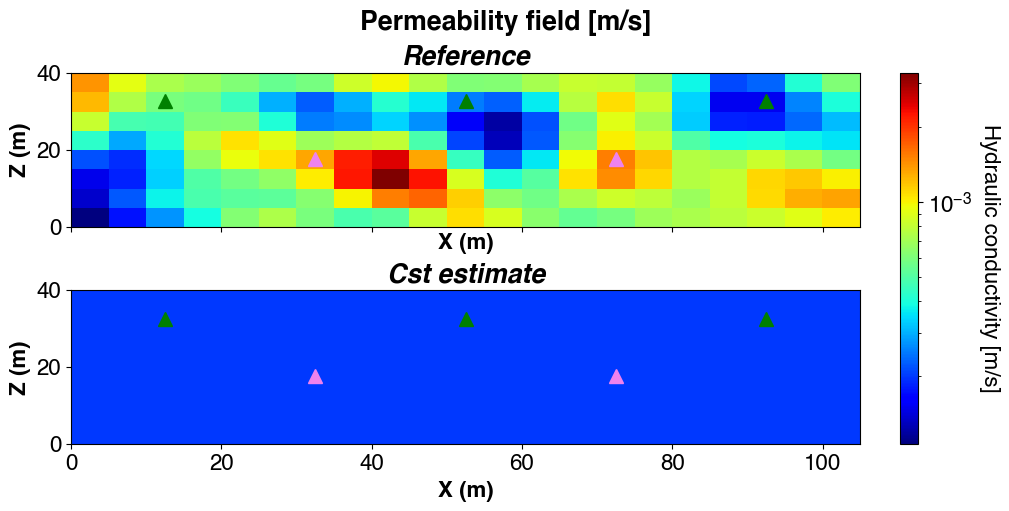

In [46]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (10, 5)},
    subplots_mosaic_params={
        "fig0": dict(mosaic=[["ax1-1"], ["ax1-2"]], sharey=True, sharex=True)
    },
)

multi_imshow(
    axes=plotter.axes,
    fig=plotter.fig,
    data={
        "Reference": perm_reference_hytec[:, :, 0, 0],
        "Cst estimate": perm_estimate_hytec[:, :, 0, 0],
    },
    cbar_title="Hydraulic conductivity [m/s]",
    imshow_kwargs={
        "cmap": plt.get_cmap("jet"),
        "extent": [0.0, nx * dx, 0.0, ny * dy],
        "norm": LogNorm(),
    },
    xlabel="X (m)",
    ylabel="Z (m)",
)

plotter.subfigs["fig0"].suptitle("Permeability field [m/s]", fontweight="bold")

for ax in plotter.ax_dict.values():
    # Add some vertical lines to indicate the well
    for well_pos in production_locations:
        ax.plot(
            well_pos[0] * dx + dx / 2,
            well_pos[1] * dy + dy / 2,
            label="prod wells",
            marker="^",
            markersize=10,
            c="violet",
            linestyle="none",
        )

    for well_pos in injection_locations:
        ax.plot(
            well_pos[0] * dx + dx / 2,
            well_pos[1] * dy + dy / 2,
            label="inj wells",
            marker="^",
            markersize=10,
            c="g",
            linestyle="none",
        )

fname = "true_vs_estimated_initial_mineral_field"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

### Head, pressure, and darcy velocities

- spatial evolution of heads

In [47]:
plotter = AnimatedPlotter(
    fig_params={"constrained_layout": True, "figsize": (15, 10)},
    subplots_mosaic_params={
        "fig0": dict(
            mosaic=[["ax1-1"], ["ax1-2"], ["ax1-3"], ["ax1-4"]],
            sharey=True,
            sharex=True,
        )
    },
)

nb_frames = min(nt + 1, 15)

plotter.animated_multi_imshow(
    ax_names=["ax1-1", "ax1-2", "ax1-3", "ax1-4"],
    fig=plotter.fig,
    data={
        # Warning: observation 0 matches sample 1
        "Reference (PyRTID)": model_reference.fl_model.head[:, :, :],
        "Reference (HYTEC)": head_reference_hytec[:, :, 0, :],
        "Initial guess (PyRTID)": model_estimate.fl_model.head[:, :, :],
        "Initial guess (HYTEC)": head_estimate_hytec[:, :, 0, :],
    },
    cbar_title="Head [m]",
    imshow_kwargs={"extent": [0.0, nx * dx, 0.0, ny * dy]},
    xlabel="X (m)",
    ylabel="Y (m)",
    nb_frames=nb_frames,
)

plotter.subfigs["fig0"].suptitle("Head field [m]", fontweight="bold")
plotter.subfigs["fig0"].supxlabel("X (m)", fontweight="bold")

plotter.close()
plotter.animate(nb_frames=nb_frames)

# Save the animation locally on the computer
fname_html = fig_save_path.joinpath(
    "head_field_reference_vs_initial_guess_animated.html"
)
writer = HTMLWriter(fps=5, embed_frames=True)
writer.frame_format = "svg"  # Ensure svg format
plotter.animation.save(str(fname_html), writer=writer)

# Display the animation
HTML(fname_html.read_text())

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


In [48]:
head_estimate_hytec[:, :, 0, 0]

array([[9., 9., 9., 9., 9., 9., 9., 9.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [9., 9., 9., 9., 9., 9., 9., 9.]])

- Pressure evolution

In [49]:
plotter = AnimatedPlotter(
    fig_params={"constrained_layout": True, "figsize": (15, 10)},
    subplots_mosaic_params={
        "fig0": dict(
            mosaic=[["ax1-1"], ["ax1-2"], ["ax1-3"], ["ax1-4"]],
            sharey=True,
            sharex=True,
        )
    },
)

nb_frames = min(nt + 1, 15)

plotter.animated_multi_imshow(
    ax_names=["ax1-1", "ax1-2", "ax1-3", "ax1-4"],
    fig=plotter.fig,
    data={
        # Warning: observation 0 matches sample 1
        "Reference (PyRTID)": model_reference.fl_model.get_pressure_pa()[:, :, :] / 1e5,
        "Reference (HYTEC)": pressure_reference_hytec[:, :, 0, :],
        "Initial guess (PyRTID)": model_reference.fl_model.get_pressure_pa()[:, :, :]
        / 1e5,
        "Initial guess (HYTEC)": pressure_estimate_hytec[:, :, 0, :],
    },
    cbar_title="Pressure [bar]",
    imshow_kwargs={"extent": [0.0, nx * dx, 0.0, ny * dy]},
    xlabel="X (m)",
    ylabel="Y (m)",
    nb_frames=nb_frames,
)

plotter.subfigs["fig0"].suptitle("Pressure [bar]", fontweight="bold")
plotter.subfigs["fig0"].supxlabel("X (m)", fontweight="bold")

plotter.close()
plotter.animate(nb_frames=nb_frames)

# Save the animation locally on the computer
fname_html = fig_save_path.joinpath(
    "pressure_field_reference_vs_initial_guess_animated.html"
)
writer = HTMLWriter(fps=5, embed_frames=True)
writer.frame_format = "svg"  # Ensure svg format
plotter.animation.save(str(fname_html), writer=writer)

# Display the animation
HTML(fname_html.read_text())

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


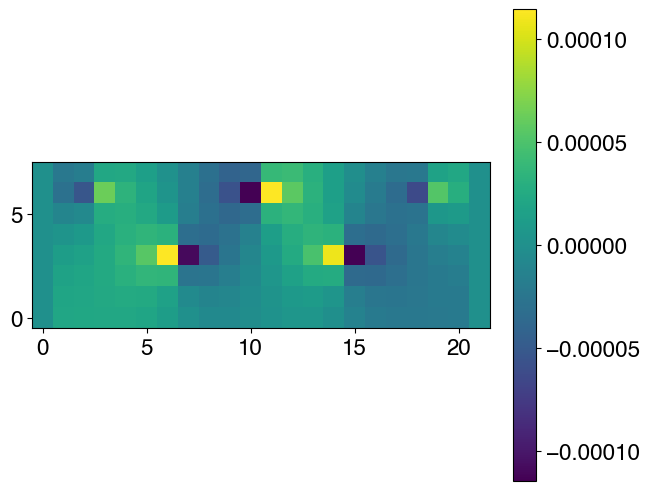

In [50]:
plt.imshow(model_estimate.fl_model.u_darcy_x[:, :, 1].T, origin="lower")
plt.colorbar()

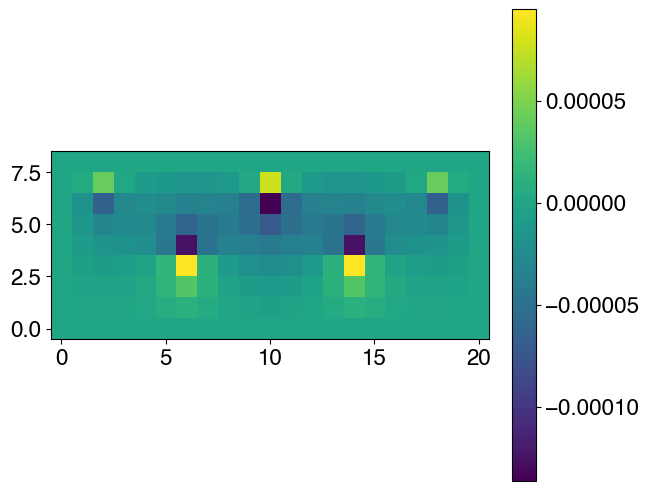

In [51]:
plt.imshow(model_estimate.fl_model.u_darcy_y[:, :, 1].T, origin="lower")
plt.colorbar()

- Concentration evolution

In [52]:
plotter = AnimatedPlotter(
    fig_params={"constrained_layout": True, "figsize": (15, 12)},
    subplots_mosaic_params={
        "fig0": dict(
            mosaic=[["ax1-1"], ["ax1-2"], ["ax1-3"], ["ax1-4"]],
            sharey=True,
            sharex=True,
        )
    },
)

nb_frames = min(nt + 1, 15)


plotter.animated_multi_imshow(
    ax_names=["ax1-1", "ax1-2", "ax1-3", "ax1-4"],
    fig=plotter.fig,
    data={
        # Warning: observation 0 matches sample 1
        "Reference (PyRTID)": model_reference.tr_model.conc[:, :, :],
        "Reference (HYTEC)": fwd_conc_reference_hytec[:, :, 0, :],
        "Initial guess (PyRTID)": model_estimate.tr_model.conc[:, :, :],
        "Initial guess (HYTEC)": fwd_conc_estimate_hytec[:, :, 0, :],
    },
    cbar_title="Tracer concentration [molal]",
    imshow_kwargs={"extent": [0.0, nx * dx, 0.0, ny * dy]},
    xlabel="X (m)",
    ylabel="Z (m)",
    nb_frames=nb_frames,
)

for ax in plotter.ax_dict.values():
    # Add some vertical lines to indicate the well
    for well_pos in production_locations:
        ax.plot(
            well_pos[0] * dx + dx / 2,
            well_pos[1] * dy + dy / 2,
            label="prod wells",
            marker="^",
            markersize=10,
            c="violet",
            linestyle="none",
        )

    for well_pos in injection_locations:
        ax.plot(
            well_pos[0] * dx + dx / 2,
            well_pos[1] * dy + dy / 2,
            label="inj wells",
            marker="^",
            markersize=10,
            c="g",
            linestyle="none",
        )

plotter.subfigs["fig0"].suptitle("Tracer concentration [molal]", fontweight="bold")
plotter.subfigs["fig0"].supxlabel("X (m)", fontweight="bold")

plotter.close()
plotter.animate(nb_frames=nb_frames)

# Save the animation locally on the computer
fname_html = fig_save_path.joinpath(
    "concentration_reference_vs_initial_guess_animated.html"
)
writer = HTMLWriter(fps=5, embed_frames=True)
writer.frame_format = "svg"  # Ensure svg format
plotter.animation.save(str(fname_html), writer=writer)

# Display the animation
HTML(fname_html.read_text())

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


- Density evolution

In [53]:
# plotter = AnimatedPlotter(
#     fig_params={"constrained_layout": True, "figsize": (15, 12)},
#     subplots_mosaic_params={
#         "fig0": dict(mosaic=[["ax1-1"], ["ax1-2"], ["ax1-3"], ["ax1-4"]], sharey=True, sharex=True)
#     },
# )

# nb_frames=min(nt +1, 15)


# plotter.animated_multi_imshow(
#     ax_names=["ax1-1", "ax1-2", "ax1-3", "ax1-4"],
#     fig=plotter.fig,
#     data={
#         # Warning: observation 0 matches sample 1
#         "Reference": density_reference_hytec[:, :, 0, :],
#         "Reference - density": density_reference_density_hytec[:, :, 0, :],
#         "Initial guess": density_estimate_hytec[:, :, 0, :],
#         "Initial guess - density": density_estimate_density_hytec[:, :, 0, :],
#     },
#     cbar_title="Tracer concentration [molal]",
#     imshow_kwargs={"extent": [0.0, nx * dx, 0.0, ny * dy]},
#     xlabel="X (m)",
#     ylabel="Z (m)",
#     nb_frames=nb_frames,
# )

# for ax in plotter.ax_dict.values():
#     # Add some vertical lines to indicate the well
#     for well_pos in production_locations:
#         ax.plot(
#             well_pos[0] * dx + dx / 2,
#             well_pos[1] * dy + dy / 2,
#             label="prod wells",
#             marker="^",
#             markersize=10,
#             c="violet",
#             linestyle="none",
#         )

#     for well_pos in injection_locations:
#         ax.plot(
#             well_pos[0] * dx + dx / 2,
#             well_pos[1] * dy + dy / 2,
#             label="inj wells",
#             marker="^",
#             markersize=10,
#             c="g",
#             linestyle="none",
#         )

# plotter.subfigs["fig0"].suptitle("Density [kg/m3]", fontweight="bold")
# plotter.subfigs["fig0"].supxlabel("X (m)", fontweight="bold")

# plotter.close()
# plotter.animate(nb_frames=nb_frames)

# # Save the animation locally on the computer
# fname_html = fig_save_path.joinpath(
#     "density_reference_vs_initial_guess_animated.html"
# )
# writer = HTMLWriter(fps=5, embed_frames=True)
# writer.frame_format = "svg"  # Ensure svg format
# plotter.animation.save(str(fname_html), writer=writer)

# # Display the animation
# HTML(fname_html.read_text())

- Add a message if rectangle 3D and y is 1 and not z -> issue with solving...

### Head and pressure at wells

- Forward variables at the producer locations

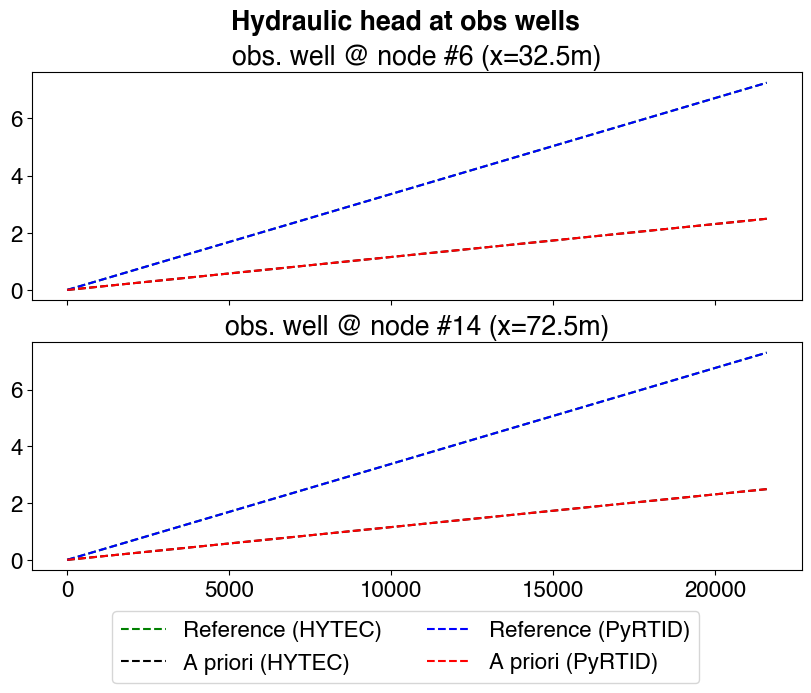

In [54]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (8, 6)},
    subplots_mosaic_params={
        "fig0": dict(
            mosaic=[["ax1-1"], ["ax2-1"]],
            sharey=False,
            sharex=True,
        )
    },
)

for i, (ix, iy, iz) in enumerate(production_locations):
    ax = plotter.get_axis(f"ax{i + 1}-1")
    x = (ix + 0.5) * dx
    y = (iy + 0.5) * dy
    z = (iz + 0.5) * dz
    obs_well_name = f"obs. well @ node #{ix} (x={x}m)"

    ax.set_title(obs_well_name)
    ax.plot(
        grid_sample_times,
        head_reference_hytec[ix, iy, iz, :],
        label="Reference (HYTEC)",
        c="g",
        linestyle="--",
    )
    ax.plot(
        grid_sample_times,
        head_estimate_hytec[ix, iy, iz, :],
        label="A priori (HYTEC)",
        c="k",
        linestyle="--",
    )
    ax.plot(
        grid_sample_times,
        model_reference.fl_model.head[ix, iy, :],
        label="Reference (PyRTID)",
        c="b",
        linestyle="--",
    )
    ax.plot(
        grid_sample_times,
        model_estimate.fl_model.head[ix, iy, :],
        label="A priori (PyRTID)",
        c="r",
        linestyle="--",
    )

plotter.fig.suptitle("Hydraulic head at obs wells", fontweight="bold")
plotter.add_fig_legend(ncol=2, bbox_y_shift=-0.02)

fname = "head_true_vs_estimate_at_obs_1D"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

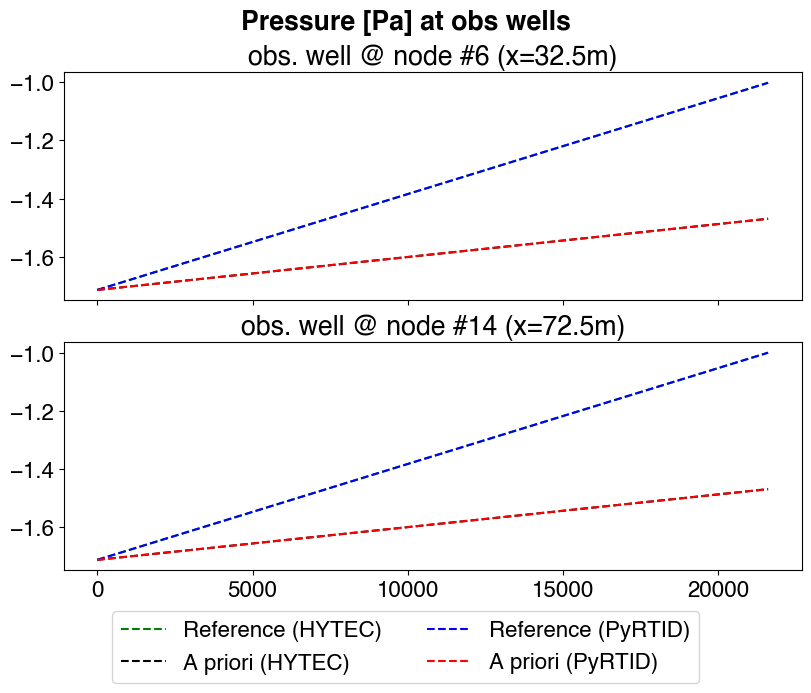

In [55]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (8, 6)},
    subplots_mosaic_params={
        "fig0": dict(
            mosaic=[["ax1-1"], ["ax2-1"]],
            sharey=False,
            sharex=True,
        )
    },
)

for i, (ix, iy, iz) in enumerate(production_locations):
    ax = plotter.get_axis(f"ax{i + 1}-1")
    x = (ix + 0.5) * dx
    y = (iy + 0.5) * dy
    z = (iz + 0.5) * dz
    obs_well_name = f"obs. well @ node #{ix} (x={x}m)"

    ax.set_title(obs_well_name)
    ax.plot(
        grid_sample_times,
        pressure_reference_hytec[ix, iy, iz, :],
        label="Reference (HYTEC)",
        c="g",
        linestyle="--",
    )
    ax.plot(
        grid_sample_times,
        pressure_estimate_hytec[ix, iy, iz, :],
        label="A priori (HYTEC)",
        c="k",
        linestyle="--",
    )
    ax.plot(
        grid_sample_times,
        model_reference.fl_model.get_pressure_bar()[ix, iy, :],
        label="Reference (PyRTID)",
        c="b",
        linestyle="--",
    )
    ax.plot(
        grid_sample_times,
        model_estimate.fl_model.get_pressure_bar()[ix, iy, :],
        label="A priori (PyRTID)",
        c="r",
        linestyle="--",
    )

plotter.fig.suptitle("Pressure [Pa] at obs wells", fontweight="bold")
plotter.add_fig_legend(ncol=2, bbox_y_shift=-0.02)

fname = "head_true_vs_estimate_at_obs_1D"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

## Inversion

- Create a function to add some noise to the observations

In [56]:
noise_std: float = 3e-4  # This is an absolute value
rng = np.random.default_rng(2021)


def get_white_noise(shape: Iterable[int]) -> NDArrayFloat:
    """
    Return the input with some added white noise.

    Note
    ----
    The parameters are hardcoded to be consistent in the notebook.
    Change the function directly.
    """
    mean_noise = 0.0  # mean
    return rng.normal(mean_noise, noise_std, shape)


# Generate a white noise
obs_noise: NDArrayFloat = get_white_noise(
    (len(production_locations), fwd_conc_estimate_hytec.shape[-1])
)

- Check the intensity of the noise

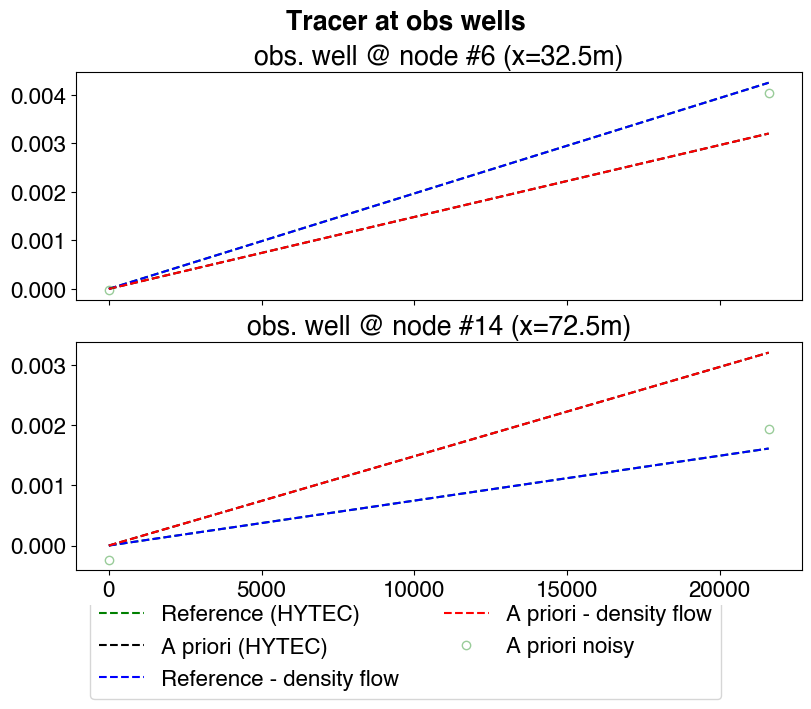

In [57]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (8, 6)},
    subplots_mosaic_params={
        "fig0": dict(
            mosaic=[["ax1-1"], ["ax2-1"]],
            sharey=False,
            sharex=True,
        )
    },
)

for i, (ix, iy, iz) in enumerate(production_locations):
    ax = plotter.get_axis(f"ax{i + 1}-1")
    x = (ix + 0.5) * dx
    y = (iy + 0.5) * dy
    z = (iz + 0.5) * dz
    obs_well_name = f"obs. well @ node #{ix} (x={x}m)"

    ax.set_title(obs_well_name)

    ax.plot(
        grid_sample_times,
        fwd_conc_reference_hytec[ix, iy, iz, :],
        label="Reference (HYTEC)",
        c="g",
        linestyle="--",
    )
    ax.plot(
        grid_sample_times,
        fwd_conc_estimate_hytec[ix, iy, iz, :],
        label="A priori (HYTEC)",
        c="k",
        linestyle="--",
    )
    ax.plot(
        grid_sample_times,
        model_reference.tr_model.conc[ix, iy, :],
        label="Reference - density flow",
        c="b",
        linestyle="--",
    )
    ax.plot(
        grid_sample_times,
        model_estimate.tr_model.conc[ix, iy, :],
        label="A priori - density flow",
        c="r",
        linestyle="--",
    )

    ax.plot(
        grid_sample_times,
        fwd_conc_reference_hytec[ix, iy, iz, :] + obs_noise[i],
        label="A priori noisy",
        c="g",
        linestyle="none",
        marker="o",
        mfc="none",
        alpha=0.4,
    )


plotter.fig.suptitle("Tracer at obs wells", fontweight="bold")
plotter.add_fig_legend(ncol=2, bbox_y_shift=-0.02)

fname = "tracer_true_vs_estimate_at_obs_1D"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

- Calcul des fonctions objectives:

### Inversion of non-density flow from pressure

In [58]:
# 1) Copy the base simulation
simu_inverse = copy.deepcopy(simu_estimate)
simu_inverse.update_root_and_name(new_root="simu_inverse", new_name="simu_inverse")

# 2) Add the observation wells
for count, (ix, iy, iz) in enumerate(production_locations):
    x: float = (ix + 0.5) * dx
    y: float = (iy + 0.5) * dy
    z: float = (iz + 0.5) * dz
    zone_name = f"producer_{ix}_{iy}_{iz}"

    vals = fwd_conc_reference_hytec[ix, iy, iz, :] + obs_noise[count]

    # Add the observables for the area
    obs = Observable(
        zone_name=zone.name,
        state_variable="T",
        units="mol/s",
        timesteps=grid_sample_times,
        time_units="s",
        obs_type=ObservationType.GRID,
        values=vals,
        uncertainties=np.ones(vals.size) * noise_std,
        node_numbers=np.repeat(
            indices_to_hytec_node_number(ix=ix, nx=nx, iy=iy, ny=ny, iz=iz), vals.size
        ),
    )
    simu_inverse.register_observable(
        zone_name, obs, obs_file_path=f"observables/{zone_name}_{species}_o.dat"
    )

# 3) Update the htc file with some options
inv_model = hymd.InverseModel(
    hymd.OptimizationStatus("enabled"),
    hymd.OptimizationSolverConfig(
        "lbfgsb",
        hymd.AdjointStateStatus("enabled"),
        hymd.FdGradientCheck("initial"),
    ),
    hymd.AdjustedParameterConfig(
        "permeability",
        hymd.Lbound(1e-8, units="m/s"),
        hymd.Ubound(1e-2, units="m/s"),
        hymd.Preconditioner("logarithmic"),
    ),
)
simu_inverse.model.add_sub_item(inv_model)

# number of samples on the adjoint variables
simu_inverse.model.get_sub_model(hymd.SamplingModel).add_sub_item(
    hymd.AdjointGridSampling(nt)
)

# 4)Write the input files
simu_inverse.write_input_files()

runner.run(simu_inverse)

# 7) Read results
simu_inverse.read_hytec_results()  # This fails if not results have been written

INFO:root:The job is over ! Elapsed time = 0:00:02.597401


- Read adjoint variable + gradient

In [59]:
ahead = simu_inverse.handlers.results.extract_field_from_adj_var_res(
    field="adjoint-variable{head} []", nx=nx, ny=ny
)

# Get the HYTEC  Adj gradient
fd_gradient = simu_inverse.handlers.results.get_fd_gradient(
    param_name="permeability", nx=nx, ny=ny
)
adjoint_gradient = simu_inverse.handlers.results.get_adjoint_gradient(
    param_name="permeability", nx=nx, ny=ny
)

### Inversion PyRTID

In [60]:
def inverse_function(x: np.ndarray) -> np.ndarray:
    """Return 1/x."""
    return 1 / x


param = pyrtid.inverse.AdjustableParameter(
    name=pyrtid.inverse.ParameterName.PERMEABILITY,
    lbound=2e-6,
    ubound=5e-3,
    preconditioner=np.log,
    preconditioner_1st_derivative=inverse_function,
    backconditioner=np.exp,
)

from typing import Dict  # Just for linting

observables = []
for i, (ix, iy, iz) in enumerate(production_locations):
    vals = model_reference.tr_model.conc[ix, iy, :] + obs_noise[i]
    timesteps = np.arange(vals.shape[0])

    observables.append(
        pyrtid.inverse.Observable(
            state_variable=pyrtid.inverse.StateVariable.CONCENTRATION,
            location=(slice(ix, ix + 1, 1), slice(iy, iy + 1)),
            timesteps=timesteps,
            values=vals,
            uncertainties=noise_std,
        )
    )


# Create an executor to keep track of the adjoint model
solver_config = dminv.ScipySolverConfig(
    solver_name="L-BFGS-B",
    solver_options={"maxfun": 20, "maxiter": 20, "ftol": 1e-4, "gtol": 1e-4},
    is_check_gradient=True,
)
model_adjusted = copy.deepcopy(model_estimate)
inverse_model = dminv.InverseModel(param, observables)
executor = dminv.ScipyInversionExecutor(model_adjusted, inverse_model, solver_config)


executor.scaled_loss_function(param.preconditioner(param.values))

is_grad_ok = executor.is_adjoint_gradient_correct()

INFO:root:- Running forward model # 1
INFO:root:- Run # 1 over
INFO:root:Loss (obs fit)        = 13.184110769731907
INFO:root:Loss (regularization) = 0.0
INFO:root:Scaling factor        = 0.07584887729370424
INFO:root:Loss (scaled)         = 0.9999999999999999



In [61]:
is_grad_ok

False

In [62]:
from pyrtid.utils import dxi_harmonic_mean


def _get_permeability_adjoint_gradient(
    fwd_model: dmfwd.ForwardModel, adj_model: dminv.AdjointModel
) -> NDArrayFloat:
    """
    Compute the gradient of the objective function with respect to the permeability.

    Parameters
    ----------
    fwd_model : ForwardModel
        The forward model which contains all forward variables and parameters.
    adj_model : AdjointModel
        The adjoint model which contains all adjoint variables and parameters.

    Note
    ----
    Parameter span is not taken into account which means that the gradient is
    computed on the full domain (grid).

    Returns
    -------
    NDArrayFloat
        Gradient of the objective function with respect to the permeability.
    """
    return _get_perm_gradient_from_diffusivity_eq(
        fwd_model, adj_model
    ) + _get_perm_gradient_from_darcy_eq(fwd_model, adj_model)


def _get_perm_gradient_from_diffusivity_eq(
    fwd_model: dmfwd.ForwardModel, adj_model: dminv.AdjointModel
) -> NDArrayFloat:
    """
    Compute the gradient with respect to the permeability using head observations.

    Parameters
    ----------
    fwd_model : ForwardModel
        The forward model which contains all forward variables and parameters.
    adj_model : AdjointModel
        The adjoint model which contains all adjoint variables and parameters.

    Note
    ----
    Parameter span is not taken into account which means that the gradient is
    computed on the full domain (grid).

    Returns
    -------
    NDArrayFloat
        Gradient with respect to the permeability using head observations.
    """
    # if not adj_model.is_head_obs:
    #     return np.zeros((fwd_model.geometry.nx, fwd_model.geometry.ny))

    shape = (fwd_model.geometry.nx, fwd_model.geometry.ny, fwd_model.time_params.nt + 1)
    permeability = fwd_model.fl_model.permeability

    crank_flow = fwd_model.fl_model.crank_nicolson

    head = fwd_model.fl_model.head
    ahead = adj_model.a_fl_model.a_head

    # Consider the x axis
    # Forward scheme
    dhead_fx = np.zeros(shape)
    dhead_fx[:-1, :, 1:] += (
        crank_flow * (head[1:, :, 1:] - head[:-1, :, 1:])
        + (1.0 - crank_flow) * (head[1:, :, :-1] - head[:-1, :, :-1])
    ) * dxi_harmonic_mean(permeability[:-1, :], permeability[1:, :])[:, :, np.newaxis]
    dahead_fx = np.zeros(shape)
    dahead_fx[:-1, :, :] += ahead[1:, :, :] - ahead[:-1, :, :]
    # Handle the stationary case
    if fwd_model.fl_model.regime == dmfwd.FlowRegime.STATIONARY:
        dhead_fx[:-1, :, :1] = (head[1:, :, :1] - head[:-1, :, :1]) * dxi_harmonic_mean(
            permeability[:-1, :], permeability[1:, :]
        )[:, :, np.newaxis]

    # Bheadkward scheme
    dhead_bx = np.zeros(shape)
    dhead_bx[1:, :, 1:] += (
        crank_flow * (head[:-1, :, 1:] - head[1:, :, 1:])
        + (1.0 - crank_flow) * (head[:-1, :, :-1] - head[1:, :, :-1])
    ) * dxi_harmonic_mean(permeability[1:, :], permeability[:-1, :])[:, :, np.newaxis]
    dahead_bx = np.zeros(shape)
    dahead_bx[1:, :, :] += ahead[:-1, :, :] - ahead[1:, :, :]
    # Handle the stationary case
    if fwd_model.fl_model.regime == dmfwd.FlowRegime.STATIONARY:
        dhead_bx[1:, :, :1] = (head[:-1, :, :1] - head[1:, :, :1]) * dxi_harmonic_mean(
            permeability[1:, :], permeability[:-1, :]
        )[:, :, np.newaxis]

    # Gather the two schemes
    grad = (
        (dhead_fx * dahead_fx + dhead_bx * dahead_bx)
        * fwd_model.geometry.dy
        / fwd_model.geometry.dx
    )

    # Consider the y axis for 2D cases
    if shape[1] != 1:
        # Forward scheme
        dhead_fy = np.zeros(shape)
        dhead_fy[:, :-1, 1:] += (
            crank_flow * (head[:, 1:, 1:] - head[:, :-1, 1:])
            + (1.0 - crank_flow) * (head[:, 1:, :-1] - head[:, :-1, :-1])
        ) * dxi_harmonic_mean(permeability[:, :-1], permeability[:, 1:])[
            :, :, np.newaxis
        ]
        dahead_fy = np.zeros(shape)
        dahead_fy[:, :-1, :] += ahead[:, 1:, :] - ahead[:, :-1, :]
        # Handle the stationary case
        if fwd_model.fl_model.regime == dmfwd.FlowRegime.STATIONARY:
            dhead_fy[:, :-1, :1] += (
                head[:, 1:, :1] - head[:, :-1, :1]
            ) * dxi_harmonic_mean(permeability[:, :-1], permeability[:, 1:])[
                :, :, np.newaxis
            ]

        # Bheadkward scheme
        dhead_by = np.zeros(shape)
        dhead_by[:, 1:, 1:] += (
            crank_flow * (head[:, :-1, 1:] - head[:, 1:, 1:])
            + (1.0 - crank_flow) * (head[:, :-1, :-1] - head[:, 1:, :-1])
        ) * dxi_harmonic_mean(permeability[:, 1:], permeability[:, :-1])[
            :, :, np.newaxis
        ]
        dahead_by = np.zeros(shape)
        dahead_by[:, 1:, :] += ahead[:, :-1, :] - ahead[:, 1:, :]
        # Handle the stationary case
        if fwd_model.fl_model.regime == dmfwd.FlowRegime.STATIONARY:
            dhead_by[:, 1:, :1] += (
                (head[:, :-1, :1] - head[:, 1:, :1])
            ) * dxi_harmonic_mean(permeability[:, 1:], permeability[:, :-1])[
                :, :, np.newaxis
            ]

        # Gather the two schemes
        grad += (
            (dhead_fy * dahead_fy + dhead_by * dahead_by)
            * fwd_model.geometry.dx
            / fwd_model.geometry.dy
        )

    # We sum along the temporal axis
    return -np.sum(grad, axis=-1)


def _get_perm_gradient_from_darcy_eq(
    fwd_model: dmfwd.ForwardModel, adj_model: dminv.AdjointModel
) -> NDArrayFloat:
    """
    Compute the gradient with respect to the permeability using mob observations.

    Mob are the mobile concentrations.

    Parameters
    ----------
    fwd_model : ForwardModel
        The forward model which contains all forward variables and parameters.
    adj_model : AdjointModel
        The adjoint model which contains all adjoint variables and parameters.

    Note
    ----
    Parameter span is not taken into account which means that the gradient is
    computed on the full domain (grid).

    Returns
    -------
    NDArrayFloat
        Gradient with respect to the permeability using mob observations.
    """
    shape = (fwd_model.geometry.nx, fwd_model.geometry.ny, fwd_model.time_params.nt + 1)
    permeability = fwd_model.fl_model.permeability

    head = fwd_model.fl_model.head
    a_u_darcy_x = adj_model.a_fl_model.a_u_darcy_x

    # Consider the x axis
    # Forward scheme
    dhead_fx = np.zeros(shape)
    dhead_fx[:-1, :, :] += (
        ((head[:-1, :, :] - head[1:, :, :]))
        * dxi_harmonic_mean(permeability[:-1, :], permeability[1:, :])[:, :, np.newaxis]
        * a_u_darcy_x
    )

    # Bconckward scheme
    dhead_bx = np.zeros(shape)
    dhead_bx[1:, :, :] -= (
        ((head[1:, :, :] - head[:-1, :, :]))
        * dxi_harmonic_mean(permeability[1:, :], permeability[:-1, :])[:, :, np.newaxis]
        * a_u_darcy_x
    )

    # Gather the two schemes
    grad = (dhead_fx + dhead_bx) / fwd_model.geometry.dx

    # Consider the y axis for 2D cases
    if shape[1] != 1:
        a_u_darcy_y = adj_model.a_fl_model.a_u_darcy_y
        # Forward scheme
        dhead_fy = np.zeros(shape)
        dhead_fy[:, :-1, :] += (
            ((head[:, :-1, :] - head[:, 1:, :]))
            * dxi_harmonic_mean(permeability[:, :-1], permeability[:, 1:])[
                :, :, np.newaxis
            ]
            * a_u_darcy_y
        )

        # Bconckward scheme
        dhead_by = np.zeros(shape)
        dhead_by[:, 1:, :] -= (
            ((head[:, 1:, :] - head[:, :-1, :]))
            * dxi_harmonic_mean(permeability[:, 1:], permeability[:, :-1])[
                :, :, np.newaxis
            ]
            * a_u_darcy_y
        )
        # Gather the two schemes
        grad += (dhead_fy + dhead_by) / fwd_model.geometry.dy

    # We sum along the temporal axis
    return -np.sum(grad, axis=-1)

In [63]:
grad = (
    _get_permeability_adjoint_gradient(executor.fwd_model, executor.adj_model) / 5 * k0
)

In [64]:
grad1 = (
    _get_perm_gradient_from_darcy_eq(executor.fwd_model, executor.adj_model) / 5 * k0
)
grad2 = (
    _get_perm_gradient_from_darcy_eq(executor.fwd_model, executor.adj_model) / 5 * k0
)

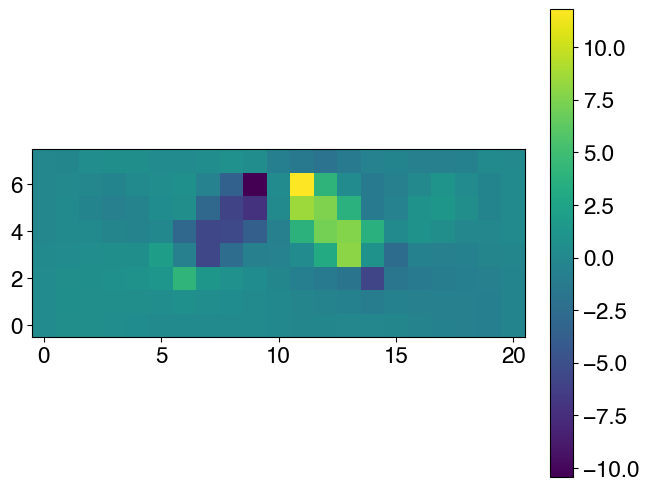

In [65]:
plt.imshow(grad.T, origin="lower")
plt.colorbar()

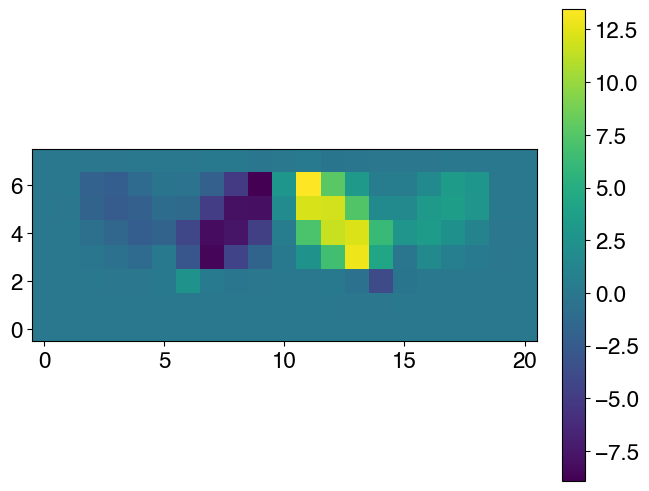

In [66]:
plt.imshow(grad2.T, origin="lower")
plt.colorbar()

In [67]:
logging.info(f"is grad ok = {is_grad_ok}")

INFO:root:is grad ok = False


In [68]:
scaling_factor = executor.inv_model.scaling_factor

- Plot the gradients

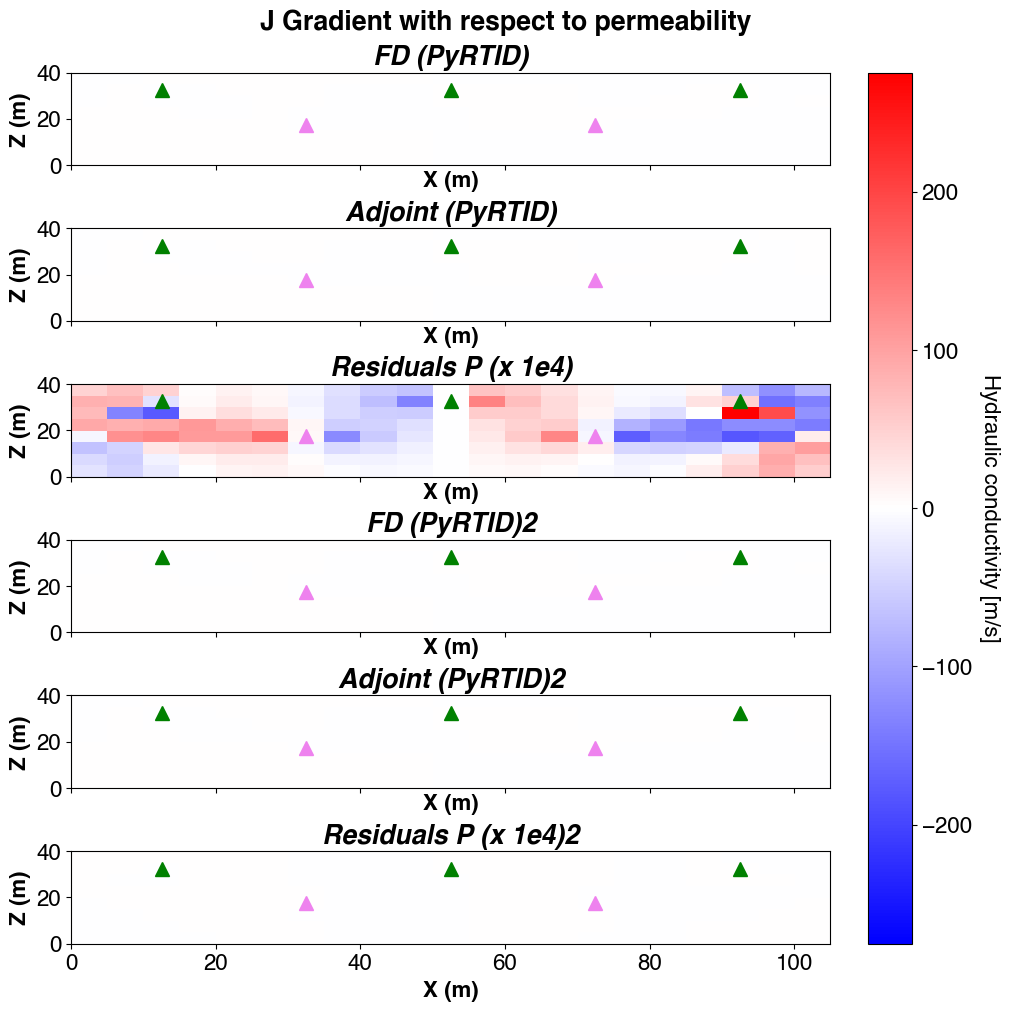

In [70]:
plotter = NestedGridPlotter(
    fig_params={"constrained_layout": True, "figsize": (10, 10)},
    subplots_mosaic_params={
        "fig0": dict(
            mosaic=[["ax1-1"], ["ax1-2"], ["ax1-3"], ["ax1-4"], ["ax1-5"], ["ax1-6"]],
            sharey=True,
            sharex=True,
        )
    },
)

multi_imshow(
    axes=plotter.axes,
    fig=plotter.fig,
    data={
        "FD (PyRTID)": param.archived_fd_gradients[0] * scaling_factor,
        "Adjoint (PyRTID)": param.archived_adjoint_gradients[0] * scaling_factor,
        "Residuals P (x 1e4)": (
            (param.archived_fd_gradients[0] - param.archived_adjoint_gradients[0])
            * scaling_factor
        )
        * 1e4,
        "FD (PyRTID)2": param.archived_fd_gradients[0] * scaling_factor,
        "Adjoint (PyRTID)2": param.archived_adjoint_gradients[0] * scaling_factor,
        "Residuals P (x 1e4)2": (
            (param.archived_fd_gradients[0] - param.archived_adjoint_gradients[0])
            * scaling_factor
        )
        * 1,
        # "FD (HYTEC)": fd_gradient[:, :, 0, 0],
        # "Adjoint (HYTEC)": adjoint_gradient[:, :, 0, 0],
        # "Residuals H (x 1e5)": (adjoint_gradient[:, :, 0, 0] - fd_gradient[:, :, 0, 0]) * 1e5,
    },
    cbar_title="Hydraulic conductivity [m/s]",
    imshow_kwargs={
        "extent": [0.0, nx * dx, 0.0, ny * dy],
    },
    xlabel="X (m)",
    ylabel="Z (m)",
    is_symetric_cbar=True,
)

plotter.subfigs["fig0"].suptitle(
    "J Gradient with respect to permeability", fontweight="bold"
)

for ax in plotter.ax_dict.values():
    # Add some vertical lines to indicate the well
    for well_pos in production_locations:
        ax.plot(
            well_pos[0] * dx + dx / 2,
            well_pos[1] * dy + dy / 2,
            label="prod wells",
            marker="^",
            markersize=10,
            c="violet",
            linestyle="none",
        )

    for well_pos in injection_locations:
        ax.plot(
            well_pos[0] * dx + dx / 2,
            well_pos[1] * dy + dy / 2,
            label="inj wells",
            marker="^",
            markersize=10,
            c="g",
            linestyle="none",
        )

fname = "j_gradient_permeability"
for format in ["png", "pdf"]:
    plotter.fig.savefig(str(fig_save_path.joinpath(f"{fname}.{format}")), format=format)

- Display Pyrtid adjoint head and adjoint tracer concentrations